# W7 fixed ablation and leakage audit

## tl;dr

동결된 94개 세포주 outer 5-fold에서 16개 비교군을 평가했다. 모든 고정
low-rank 변형은 B1 평균 반응보다 나았지만 B4 direct ridge를 확실히 넘지 못했다.
Pathway panel의 B4 대비 RMSE gain은 `-0.000251`
(95% CI `-0.000598–0.000127`),
lineage 추가는 `-0.000295`, BRAF/KRAS 추가는
`-0.000127`다. 따라서 W7은 외부 정보가 격차를
줄일 가능성은 보이지만 B4 우위나 새 주 모델을 확정하지 않는다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/ablation_summary.json").read_text())
comparison = pd.read_csv(root / "results/tables/ablation_metrics.csv")
variants = pd.read_csv(root / "results/tables/ablation_variants.csv")
coverage = pd.read_csv(root / "results/tables/pathway_panel_coverage.csv")
enrichment = pd.read_csv(root / "results/tables/component_pathway_enrichment.csv")
stability = pd.read_csv(root / "results/tables/cclr_subspace_stability.csv")
display(comparison[[
    "model", "rmse_delta_mean", "pcc_context_mean",
    "rmse_gain_vs_b1_mean", "rmse_gain_vs_b1_ci95_low", "rmse_gain_vs_b1_ci95_high",
    "rmse_gain_vs_b4_mean", "rmse_gain_vs_b4_ci95_low", "rmse_gain_vs_b4_ci95_high",
]])
assert summary["cell_lines"] == 94
assert summary["variants"] == 16
assert summary["outer_test_response_used_for_fit"] is False
assert summary["outer_test_used_for_variant_selection"] is False


,model,rmse_delta_mean,pcc_context_mean,rmse_gain_vs_b1_mean,rmse_gain_vs_b1_ci95_low,rmse_gain_vs_b1_ci95_high,rmse_gain_vs_b4_mean,rmse_gain_vs_b4_ci95_low,rmse_gain_vs_b4_ci95_high
0,B1_MEAN_W5,0.323750,NaN,0.000000,0.000000,0.000000,-0.001715,-0.002277,-0.001196
1,B4_DIRECT_RIDGE_W5,0.322035,0.107666,0.001715,0.001179,0.002255,0.000000,0.000000,0.000000
2,CCLR_NESTED_W6,0.322383,0.096521,0.001367,0.000797,0.001933,-0.000348,-0.000585,-0.000108
3,FIXED_FULL_D20_R20,0.322350,0.099763,0.001399,0.000802,0.001987,-0.000315,-0.000612,-0.000044
4,CONTROL_D05_R20,0.322423,0.090011,0.001327,0.000926,0.001782,-0.000388,-0.000645,-0.000155
5,CONTROL_D10_R20,0.322314,0.098641,0.001436,0.000902,0.001984,-0.000279,-0.000425,-0.000140
6,CONTROL_D30_R20,0.322364,0.100391,0.001385,0.000755,0.001998,-0.000330,-0.000651,-0.000008
7,RANK_D20_R02,0.322829,0.071810,0.000920,0.000475,0.001364,-0.000795,-0.001140,-0.000451
8,RANK_D20_R05,0.322635,0.081292,0.001115,0.000591,0.001631,-0.000600,-0.000985,-0.000231
9,RANK_D20_R10,0.322532,0.089371,0.001218,0.000705,0.001736,-0.000497,-0.000810,-0.000180


## Context & Methods

W7은 W6 결과를 소급 재튜닝하는 단계가 아니라 같은 frozen outer test에서 모델의
어떤 제약과 입력이 성능을 바꾸는지 확인하는 진단 분석이다.

### Key Assumptions

- 기준점은 control dimension 20, response rank 20, ridge alpha 100이다.
- control dimension `[5, 10, 20, 30]`과 response rank `[2, 5, 10, 20, 30, 40, 50]`을 모두 보고한다.
- rank 30/40/50은 W6의 rank 20 상한 선택 뒤 사전 동결한 진단 확장이며 W6 주 결과를 바꾸지 않는다.
- MSigDB Hallmark 2026.1.Hs 6개 source set과 기존 8개 immediate-early marker를
  결과 확인 전에 동결했다.
- pathway 입력만 제한하고 response target은 모든 32,738 genes로 유지한다.
- lineage one-hot과 BRAF/KRAS 표준화는 각 outer-training fold에서만 fit한다.
- outer-test response와 sensitivity는 predictor나 variant 선택에 사용하지 않는다.
- 모든 변형을 보고하며 outer-test 평균이 가장 좋은 변형을 새 주 모델로 승격하지 않는다.

## Data

In [3]:
annotations = pd.read_csv(root / "cell_line_annotations.csv")
display(pd.DataFrame({
    "field": ["cell lines", "lineages", "BRAF mutant", "KRAS mutant"],
    "value": [len(annotations), annotations["lineage"].nunique(),
              int(annotations["braf_mut"].sum()), int(annotations["kras_mut"].sum())],
}))
display(coverage)
assert coverage.loc[coverage["row_type"].eq("panel_union"), "defined_symbols"].iloc[0] == 1039
assert coverage.loc[coverage["row_type"].eq("panel_union"), "mapped_symbols"].iloc[0] == 1001


,field,value
0,cell lines,94
1,lineages,21
2,BRAF mutant,8
3,KRAS mutant,19


,row_type,collection,outer_fold,defined_symbols,mapped_symbols,mapped_matrix_columns,selected_training_columns
0,collection,MAPK_KRAS_signaling,NaN,400,384,386,NaN
1,collection,E2F_targets,NaN,200,195,196,NaN
2,collection,G2M_checkpoint,NaN,200,187,190,NaN
3,collection,apoptosis,NaN,161,159,159,NaN
4,collection,epithelial_mesenchymal_transition,NaN,200,195,196,NaN
5,collection,immediate_early_response,NaN,8,8,8,NaN
6,panel_union,all_input_collections,NaN,1039,1001,1007,NaN
7,outer_training_selection,all_input_collections,0.0,1039,1001,1007,918.0
8,outer_training_selection,all_input_collections,1.0,1039,1001,1007,917.0
9,outer_training_selection,all_input_collections,2.0,1039,1001,1007,924.0


## Results

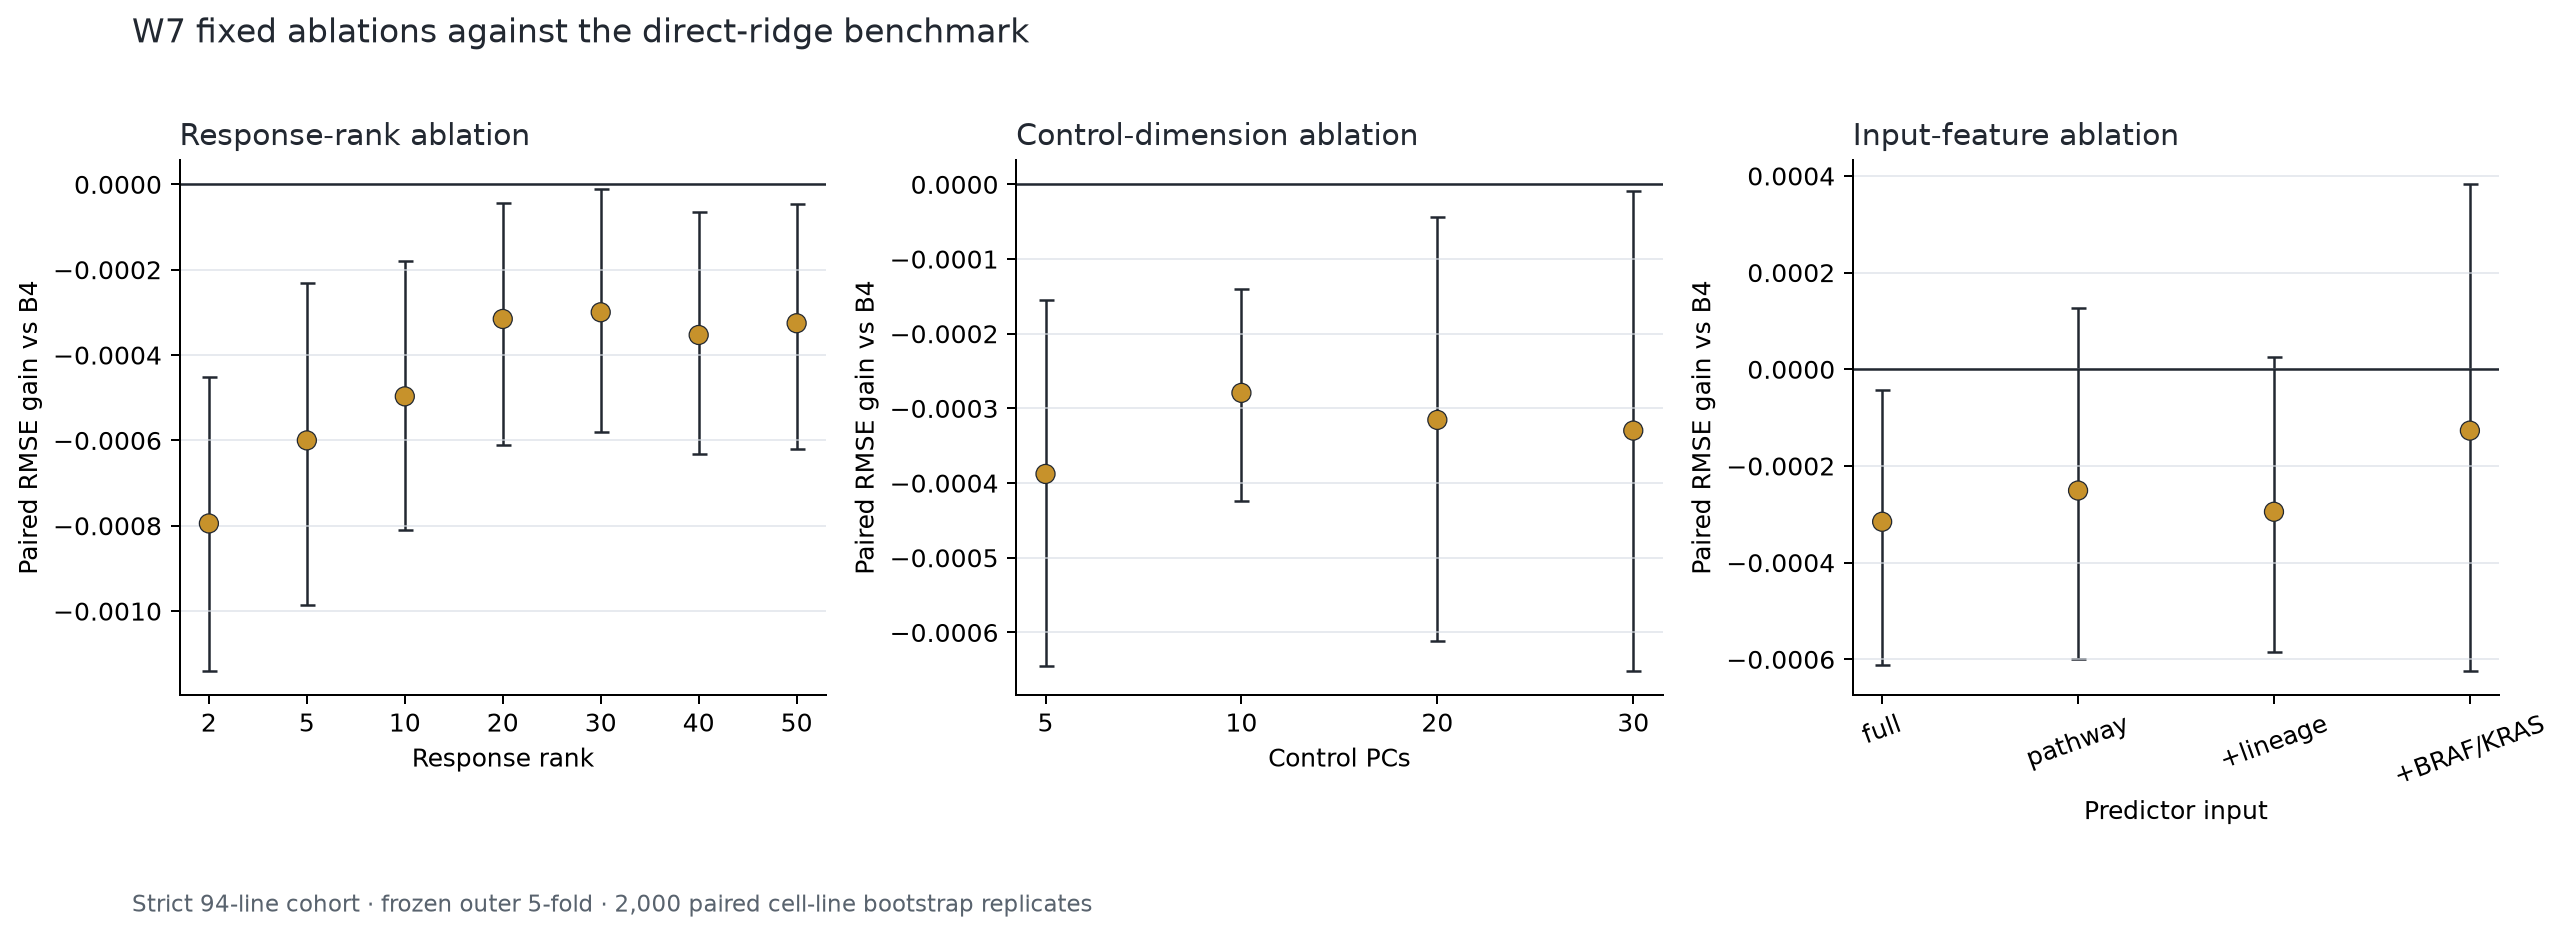

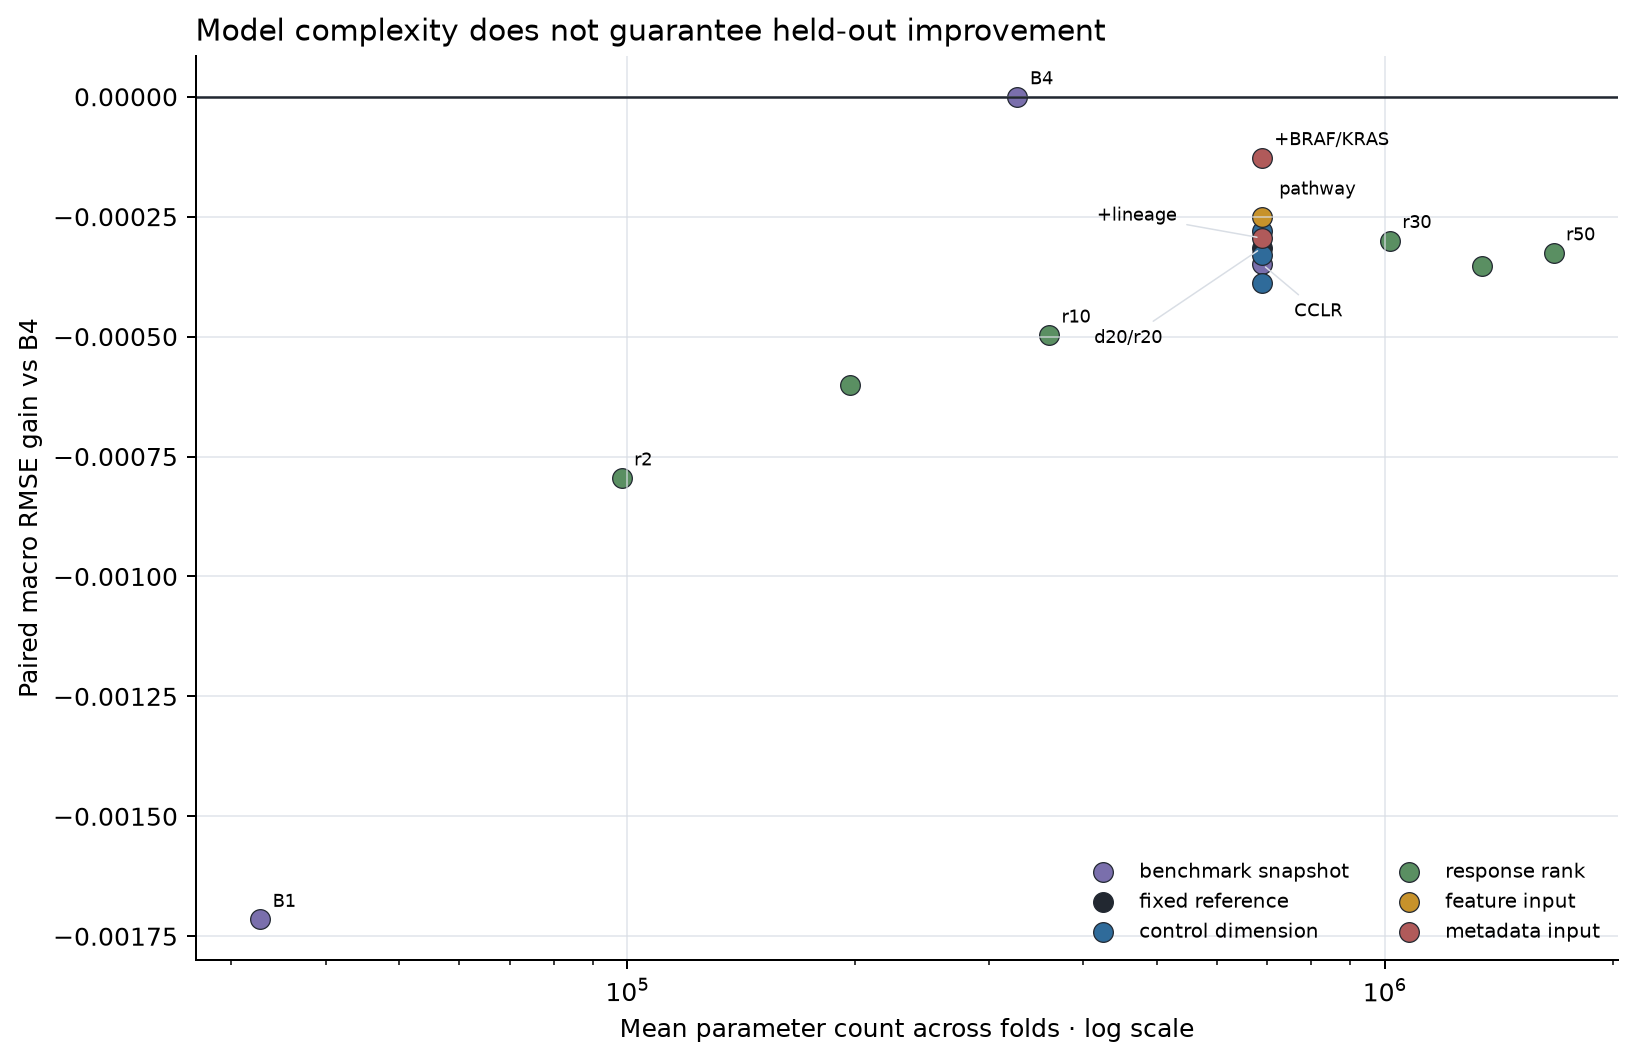

,model,family,parameter_count_mean,rmse_delta_mean,rmse_gain_vs_b4_mean
0,B1_MEAN_W5,benchmark_snapshot,32738.0,0.323750,-0.001715
1,B4_DIRECT_RIDGE_W5,benchmark_snapshot,327380.0,0.322035,0.000000
2,CCLR_NESTED_W6,benchmark_snapshot,687858.0,0.322383,-0.000348
3,FIXED_FULL_D20_R20,fixed_reference,687918.0,0.322350,-0.000315
4,CONTROL_D05_R20,control_dimension,687618.0,0.322423,-0.000388
5,CONTROL_D10_R20,control_dimension,687718.0,0.322314,-0.000279
6,CONTROL_D30_R20,control_dimension,688118.0,0.322364,-0.000330
7,RANK_D20_R02,response_rank,98256.0,0.322829,-0.000795
8,RANK_D20_R05,response_rank,196533.0,0.322635,-0.000600
9,RANK_D20_R10,response_rank,360328.0,0.322532,-0.000497


In [4]:
display(Image(filename=str(root / "results/figures/ablation_performance.png")))
display(Image(filename=str(root / "results/figures/complexity_vs_performance.png")))
display(variants[[
    "model", "family", "parameter_count_mean", "rmse_delta_mean", "rmse_gain_vs_b4_mean"
]])


### Pathway enrichment and fold stability

direction,negative,positive
collection,,
E2F_targets,3,6
G2M_checkpoint,5,9
MAPK_KRAS_signaling,14,18
apoptosis,3,7
epithelial_mesenchymal_transition,15,15
immediate_early_response,4,5


,outer_fold_a,outer_fold_b,common_rank,mean_squared_cosine,minimum_cosine,maximum_cosine
0,0,1,20,0.688820,0.002540,0.999824
1,0,2,20,0.755441,0.001598,0.999787
2,0,3,20,0.685420,0.016970,0.999842
3,0,4,20,0.699081,0.019940,0.999785
4,1,2,20,0.676292,0.010891,0.999762
5,1,3,20,0.627026,0.007672,0.999876
6,1,4,20,0.642816,0.003504,0.999816
7,2,3,20,0.658408,0.006477,0.999877
8,2,4,20,0.697778,0.013145,0.999751
9,3,4,20,0.629281,0.014730,0.999873


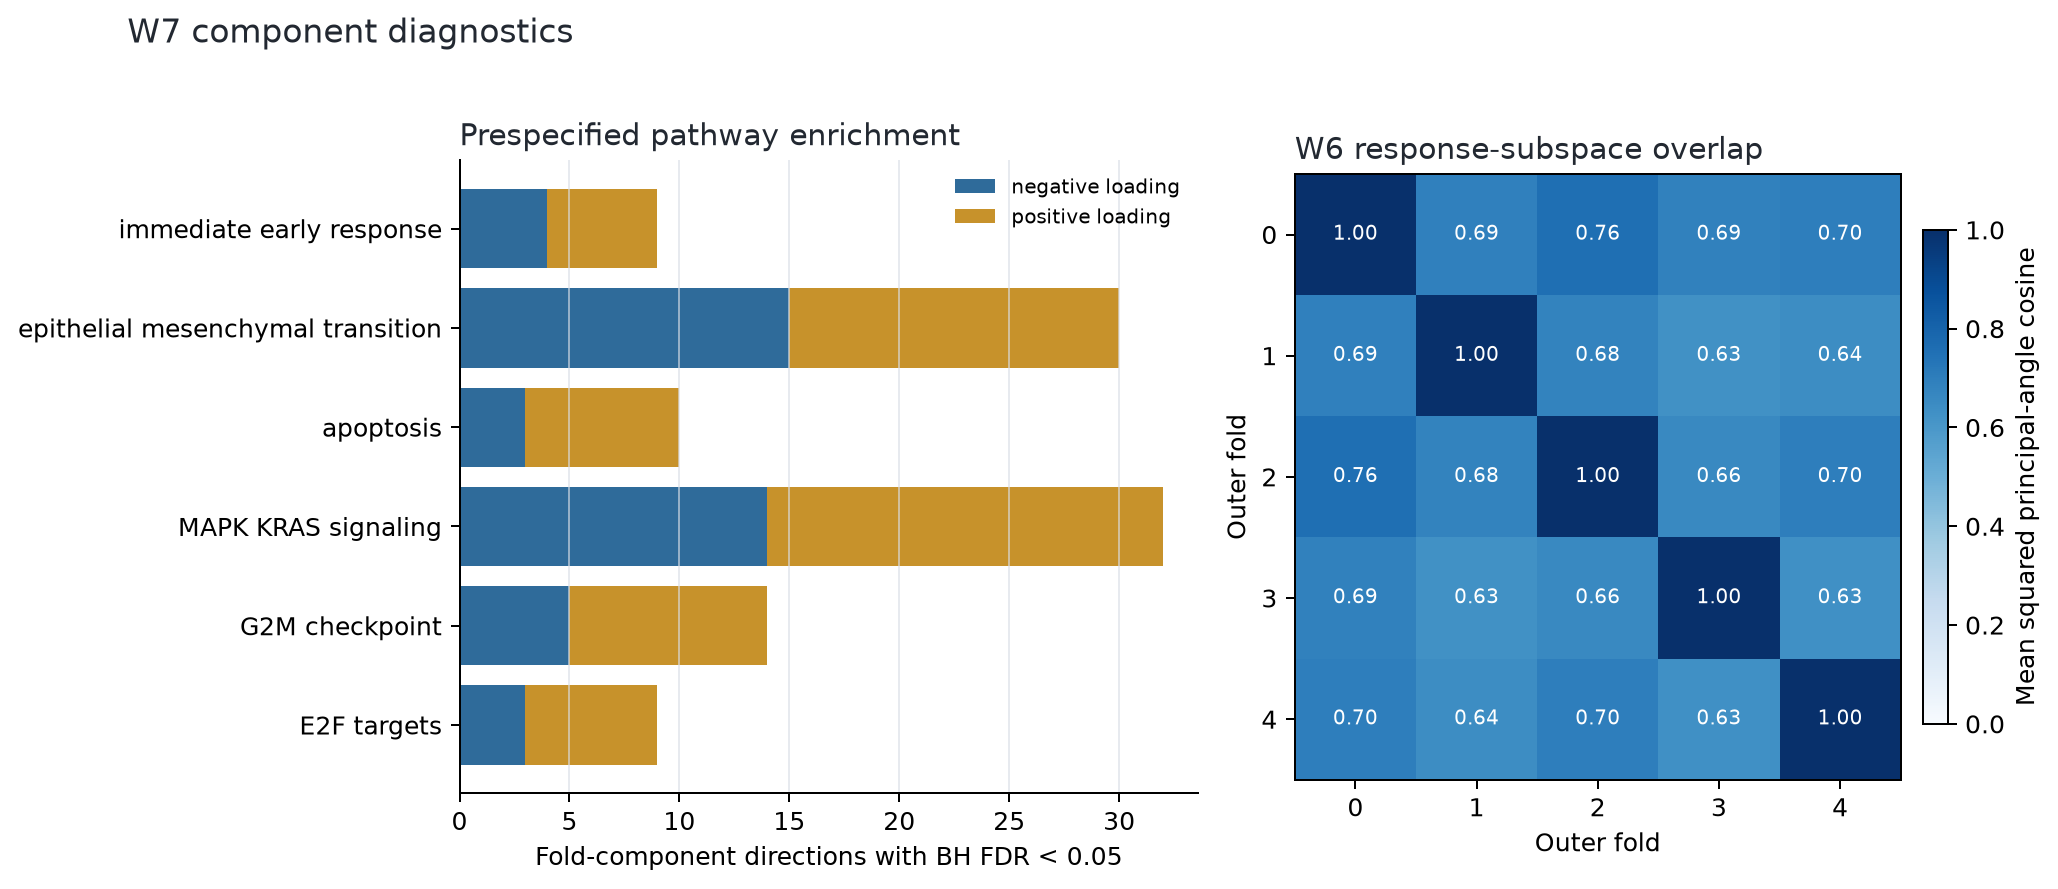

Mean fold-pair response-subspace overlap: 0.6760362032498425


In [5]:
significant = (
    enrichment.assign(significant=enrichment["fdr_bh"].lt(0.05))
    .groupby(["collection", "direction"])["significant"].sum().unstack(fill_value=0)
)
display(significant)
display(stability)
display(Image(filename=str(root / "results/figures/component_diagnostics.png")))
print("Mean fold-pair response-subspace overlap:", stability["mean_squared_cosine"].mean())


## Takeaways

- control dimension은 10–30 사이에서 차이가 작고, rank 20을 30–50으로 늘려도
  B4를 따라잡지 못한다. W6 상한 선택이 큰 미탐색 이득을 숨겼다는 근거는 없다.
- pathway panel은 평균 격차를 줄였지만 B4 대비 CI
  `-0.000598–0.000127`가
  0을 포함한다.
- BRAF/KRAS 추가 변형이 고정 low-rank 변형 중 평균 RMSE가 가장 낮지만, B4 대비 CI
  `-0.000624–0.000383`가
  넓게 0을 포함한다. test 결과로 고른 관찰이므로 새 주 모델로 승격하지 않는다.
- W6 response subspace의 fold-pair mean squared cosine은 평균 약 `0.676`이다.
  상위 방향은 안정적이지만 최약 방향은 거의 정렬되지 않아 component 번호별 강한 해석은 피한다.
- 사전 정의 pathway enrichment는 반복 검출되지만, 예측 정확도 개선과 생물학적
  enrichment를 동일한 주장으로 취급하지 않는다.